In [43]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

In [52]:
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def krons(ops):
    res = ops[0]
    for op in ops[1:]:
        res = np.kron(res, op)
    return res

def to_density(vec):
    return np.outer(vec, vec.conj())

def generate_paulis(n, model="quantum"):
    """
    Generates Pauli strings for an n-qubit system.
    Includes nearest neightbor ZZ interactions, 1-body field terms, and Identity.
    """
    paulis = []
    if model == "quantum":
        base_ops = [X, Y, Z]
    elif model == "classical":
        base_ops = [Z]

    # nearest neighbor Interactions
    for op in base_ops: 
        for i in range(n - 1):
            op_list = [I] * n
            op_list[i] = op
            op_list[i+1] = op
            paulis.append(krons(op_list))
            
    # 1-body Interactions
    for op in base_ops:
        for i in range(n):
            op_list = [I] * n
            op_list[i] = op
            paulis.append(krons(op_list))
        
    # Identity term
    paulis.append(krons([I] * n))
    
    return paulis

def make_training_states(n):
    states = []
    dim = 2**n
    k0, k1 = np.array([1, 0]), np.array([0, 1])
    kp, km = np.array([1, 1])/np.sqrt(2), np.array([1, -1])/np.sqrt(2)

    # Computational basis states
    for bits in itertools.product([k0, k1], repeat=n):
        states.append(to_density(krons(bits)))
    
    # +/- basis states
    for bits in itertools.product([kp, km], repeat=n):
        states.append(to_density(krons(bits)))

    # GHZ state: (|00...0> + |11...1>) / sqrt(2)
    ghz_0 = krons([k0] * n)
    ghz_1 = krons([k1] * n)
    ghz = (ghz_0 + ghz_1) / np.sqrt(2)
    states.append(to_density(ghz))
    
    # Maximally mixed state
    states.append(np.eye(dim, dtype=complex) / dim)
    
    # Random mixed states
    for _ in range(3):
        A = np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim)
        rho = A @ A.conj().T
        states.append(rho / np.trace(rho))

    for _ in range(20):
        vec = np.random.randn(dim) + 1j * np.random.randn(dim)
        vec /= np.linalg.norm(vec)
        states.append(np.outer(vec, vec.conj()))

    return np.array(states)

def fdd_logloss_matrix(y, T, eigenvalues):
    l = eigenvalues.reshape(-1, 1)
    k = eigenvalues.reshape(1, -1)
    diff = l - k
    
    with np.errstate(divide='ignore', invalid='ignore'):
        res = (T*np.log(1+np.exp(-y*l/T)) - T*np.log(1+np.exp(-y*k/T))) / diff
    derivative = -y / (1 + np.exp(y*l/T))
    
    mask = np.abs(diff) < 1e-10
    res = np.where(mask, derivative, res)
    
    return res

def dfj(y, rho, eigvals, eigvecs, H_j_basis, T):
    H_j_tilde = eigvecs.T.conj() @ (H_j_basis / T) @ eigvecs
    rho_tilde = eigvecs.T.conj() @ rho @ eigvecs
    F = fdd_logloss_matrix(y, T, eigvals)
    return np.real(np.sum(F * H_j_tilde * rho_tilde.T))

In [53]:
def make_validation_set(n, num_states=500):
    states = []
    dim = 2**n
    
    for _ in range(num_states):
        vec = np.random.randn(dim) + 1j * np.random.randn(dim)
        vec /= np.linalg.norm(vec)
        states.append(np.outer(vec, vec.conj()))
        
    kp, km = np.array([1, 1])/np.sqrt(2), np.array([1, -1])/np.sqrt(2)
    import itertools
    for bits in itertools.product([kp, km], repeat=n):
        for _ in range(10): 
            states.append(to_density(krons(bits)))
            
    return np.array(states)

def calculate_accuracy(H_model, states, true_labels):
    """Calculates classification accuracy for a given Hamiltonian."""
    energies = np.array([np.real(np.trace(H_model @ rho)) for rho in states])
    predictions = np.sign(energies)
    predictions[predictions == 0] = 1 
    return np.mean(predictions == true_labels) * 100

In [54]:
def optimize(n=3):
    np.set_printoptions(suppress=True, precision=5)
    
    # Generate Hamiltonians
    pauli_q = generate_paulis(n, model="quantum")
    pauli_c = generate_paulis(n, model="classical")

    training_states = make_training_states(n)
    N_states = len(training_states)
    val_states = make_validation_set(n, num_states=50)
    T = 2.0
    
    # compute target Hamiltonian and function outputs
    target_p = (np.random.random(len(pauli_q)) - 0.5) * 4
    H_target = sum(p * mat for p, mat in zip(target_p, pauli_q))
    ys = np.array([np.sign(np.real(np.trace(H_target @ rho))) for rho in training_states])
    ys[ys == 0] = 1

    ys_val = np.array([np.sign(np.real(np.trace(H_target @ rho))) for rho in val_states])
    ys_val[ys_val == 0] = 1

    # initialize random parameters for quantum and classical Hamiltonian
    est_q = (np.random.random(len(pauli_q)) - 0.5)
    est_c = (np.random.random(len(pauli_c)) - 0.5)
    
    epochs = 200  
    eta = 0.1       
    
    v_q = np.zeros(len(pauli_q))
    v_c = np.zeros(len(pauli_c))

    history_q = []
    history_c = []

    print(f"--- Running Optimization for {n} Qubits ---")
    print(f"{'Epoch':<6} | {'Q Loss':<10} | {'C Loss':<10} | {'Q Acc (%)':<10} | {'C Acc (%)':<10}")    
    print("-" * 60)
    
    for epoch in range(epochs):
        # --- Quantum Pass ---
        H_q = sum(p * mat for p, mat in zip(est_q, pauli_q)) 
        eval_q, evec_q = np.linalg.eigh(H_q)
        l_q = 0
        for i in range(N_states):
            yi = ys[i]
            m_loss_q = evec_q @ np.diag(T * np.log(1 + np.exp(-yi * eval_q / T))) @ evec_q.T.conj()
            l_q += np.real(np.trace(m_loss_q @ training_states[i]))
        l_q /= N_states
        history_q.append(l_q)
        
        grad_q = np.zeros(len(pauli_q))
        for j in range(len(pauli_q)):
            g_j = sum(dfj(ys[i], training_states[i], eval_q, evec_q, pauli_q[j], T) for i in range(N_states))
            grad_q[j] = g_j / N_states
            
        est_q -= eta * grad_q

        # --- Classical Pass ---
        H_c = sum(p * mat for p, mat in zip(est_c, pauli_c))
        eval_c, evec_c = np.linalg.eigh(H_c)

        l_c = 0.0
        for i in range(N_states):
            yi = ys[i]
            m_loss_c = evec_c @ np.diag(T * np.log(1 + np.exp(-yi * eval_c / T))) @ evec_c.T.conj()
            l_c += np.real(np.trace(m_loss_c @ training_states[i]))
        l_c /= N_states
        history_c.append(l_c)
        
        grad_c = np.zeros(len(pauli_c))
        for j in range(len(pauli_c)):
            g_j = sum(dfj(ys[i], training_states[i], eval_c, evec_c, pauli_c[j], T) for i in range(N_states))
            grad_c[j] = g_j / N_states
            
        est_c -= eta * grad_c

        if epoch % 20 == 0:
            q_acc = calculate_accuracy(H_q, val_states, ys_val)
            c_acc = calculate_accuracy(H_c, val_states, ys_val)
            print(f"{epoch:<6} | {l_q:<10.5f} | {l_c:<10.5f} | {q_acc:<10.2f} | {c_acc:<10.2f}")

    print("\n--- Final Results ---")
    final_H_q = sum(p * mat for p, mat in zip(est_q, pauli_q)) / T
    final_H_c = sum(p * mat for p, mat in zip(est_c, pauli_c)) / T
    
    print(f"Final Quantum Validation Accuracy:   {calculate_accuracy(final_H_q, val_states, ys_val):.2f}%")
    print(f"Final Classical Validation Accuracy: {calculate_accuracy(final_H_c, val_states, ys_val):.2f}%")
    print("\nTarget Params: ", target_p)
    print("Estimated Q:   ", est_q)
    print("Estimated C:   ", est_c)
    return history_q, history_c;

In [55]:
def plot(history_q, history_c, n):
    plt.figure(figsize=(10, 6))
    plt.plot(history_q, label='Quantum Model', color='blue', linewidth=2)
    plt.plot(history_c, label='Classical Model', color='red', linewidth=2, linestyle='--')
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel(f'Logistic Loss ({n} Qubits)', fontsize=20)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)    
    plt.yscale('log')
    plt.legend(fontsize=14)
    plt.savefig(f"plots/logloss_{n}qubit_heisenberg.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [65]:
n = 7
history_q, history_c = optimize(n);

--- Running Optimization for 7 Qubits ---
Epoch  | Q Loss     | C Loss     | Q Acc (%)  | C Acc (%) 
------------------------------------------------------------
0      | 1.48986    | 1.55304    | 62.26      | 32.33     
20     | 1.37812    | 1.45262    | 71.13      | 32.63     
40     | 1.28862    | 1.37299    | 78.20      | 66.24     
60     | 1.21727    | 1.31024    | 76.69      | 67.67     
80     | 1.16043    | 1.26093    | 80.45      | 67.67     
100    | 1.11499    | 1.22213    | 84.96      | 67.67     
120    | 1.07847    | 1.19152    | 85.71      | 67.67     
140    | 1.04892    | 1.16724    | 85.71      | 67.67     
160    | 1.02481    | 1.14787    | 84.96      | 67.67     
180    | 1.00499    | 1.13233    | 84.21      | 67.67     

--- Final Results ---
Final Quantum Validation Accuracy:   83.46%
Final Classical Validation Accuracy: 67.67%

Target Params:  [ 1.83566 -0.6262  -0.38075 -1.38387 -0.45502  0.97211  0.7306   0.10814
  0.86066  0.43203  1.66139  0.98398 -0.33125  

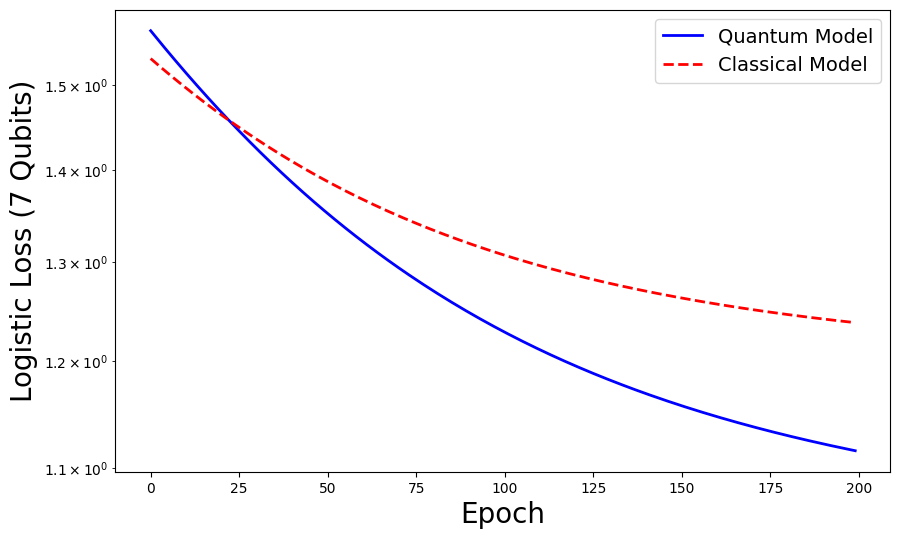

In [60]:
plot(history_q, history_c, n)